In [ ]:
# ===============================
# Case Outcome Prediction Analysis
# Exploratory Data Analysis
# ===============================

# Author: Shelly Resurreccion
# Purpose: Predictive modeling of case outcomes using classification algorithms on structured legal case data.

In [ ]:
# =====================================================
# Import libraries
# =====================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Set plot style
sns.set(style='whitegrid')

In [ ]:
# =====================================================
# Load the dataset
# =====================================================
data = pd.read_csv('../00_data/synthetic_case_outcomes.csv')
print("Dataset shape:", data.shape)
data.head()

Dataset shape: (500, 11)


,case_id,case_type,court_level,filing_year,num_parties,has_jury,num_legal_reps,duration_days,settled_pre_trial,prior_cases_same_party,outcome
0,1001,family,trial,2020,4,True,2,363,True,1,settled
1,1002,contract,trial,2021,3,False,2,153,False,6,defendant_win
2,1003,civil,trial,2015,3,False,1,143,False,9,defendant_win
3,1004,family,appeal,2015,4,False,1,307,True,3,settled
4,1005,family,trial,2015,4,False,2,242,False,9,plaintiff_win


In [ ]:
# =====================================================
# Preprocessing
# =====================================================
# Encode categorical features
categorical_cols = ['case_type', 'court_level', 'has_jury', 'settled_pre_trial']
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le

# Encode target variable
target_le = LabelEncoder()
data['outcome'] = target_le.fit_transform(data['outcome'])


In [ ]:
# =====================================================
# Split data into train/test sets
# =====================================================
X = data.drop(['case_id', 'outcome'], axis=1)
y = data['outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# =====================================================
# Train a Random Forest Classifier
# =====================================================
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Classification Report:

               precision    recall  f1-score   support

defendant_win       0.39      0.46      0.42        26
plaintiff_win       0.33      0.38      0.36        26
      settled       0.95      0.77      0.85        48

     accuracy                           0.59       100
    macro avg       0.56      0.54      0.54       100
 weighted avg       0.64      0.59      0.61       100



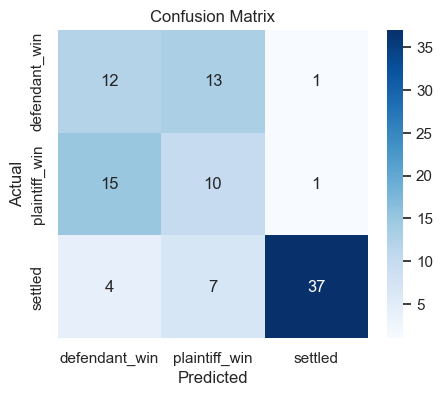

In [ ]:
# =====================================================
# Evaluate the model
# =====================================================
y_pred = clf.predict(X_test)

print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=target_le.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_le.classes_,
            yticklabels=target_le.classes_)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

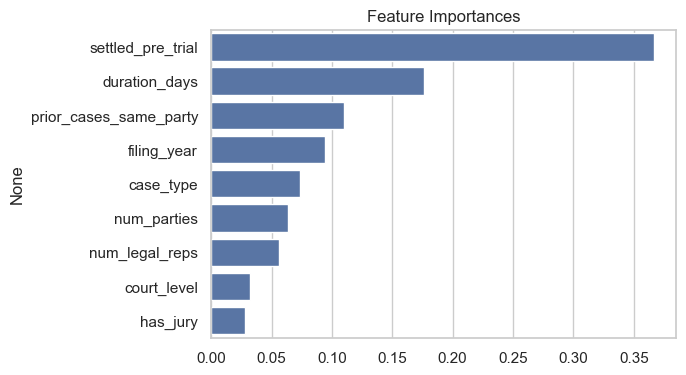

In [ ]:
# =====================================================
# Feature Importance
# =====================================================
feat_importances = pd.Series(clf.feature_importances_, index=X.columns)
feat_importances = feat_importances.sort_values(ascending=False)

plt.figure(figsize=(6,4))
sns.barplot(x=feat_importances.values, y=feat_importances.index)
plt.title('Feature Importances')
plt.show()